# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import title
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

In [5]:
df = pd.read_csv(fp)
df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [29]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

Text(0.5, 1.0, 'Attack vs Defense')

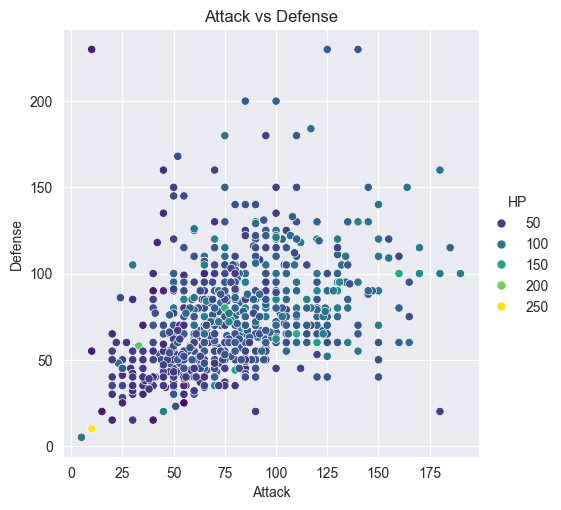

In [8]:
g = sns.relplot( data=df, x='Attack',  y='Defense', hue='HP',  palette='viridis')
plt.title("Attack vs Defense")

### From the plot, I observed there is a mostly positive correlation between attack and defense hp levels and most are clustered in the same areas
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

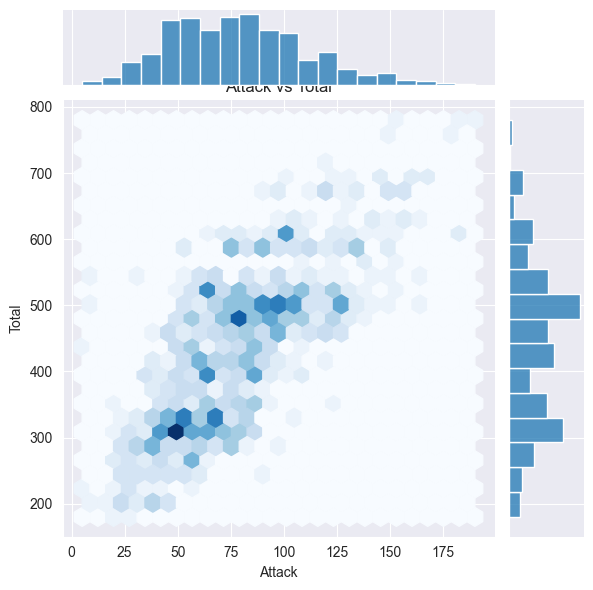

In [16]:
g = sns.jointplot( data=df,x='Attack', y='Total',  kind='hex',  gridsize=25, cmap='Blues')
plt.title("Attack vs Total")
plt.show()


From the plot, I observed there is a positive corelation between atacks and total damage. We see most the cluster in the middle.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

/var/folders/_r/1q92lm0n4hn0yyhhjw8xyy9m0000gn/T/ipykernel_72094/1486179857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot( data=df, y='Type 1', order=df['Type 1'].value_counts().index, palette='dark:salmon_r'


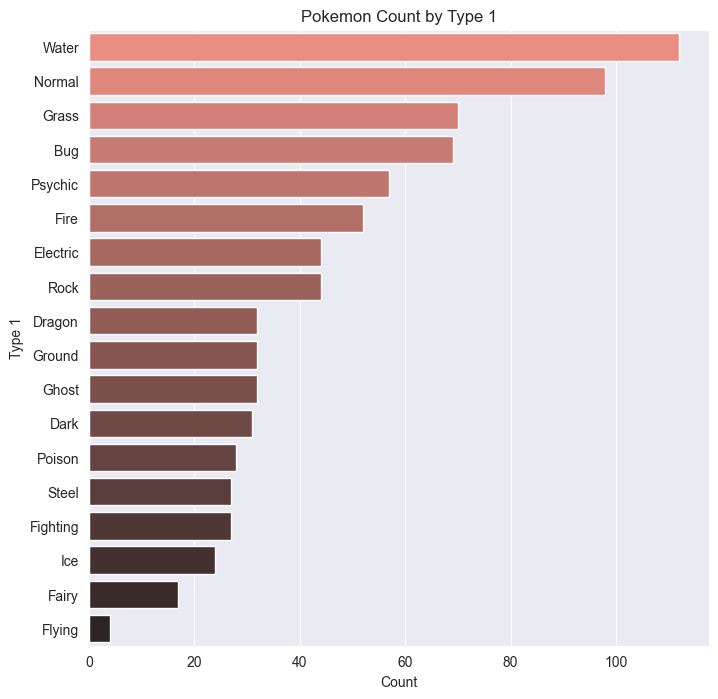

In [18]:
plt.figure(figsize=(8, 8)) #much better this way lol


sns.countplot( data=df, y='Type 1', order=df['Type 1'].value_counts().index, palette='dark:salmon_r')
plt.title('Pokemon Count by Type 1')
plt.xlabel('Count')
plt.show()

This graph shows us the number of cards per type of pokemon, and we can certainly see a wide distribution across all parts. We can see you get Water the most, followed by Normal, and flying pokemon the least

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

## Q4. Which pokemons has the highest HP

/var/folders/_r/1q92lm0n4hn0yyhhjw8xyy9m0000gn/T/ipykernel_72094/4275019998.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Type 2', y='HP', order=type_order, palette='viridis')


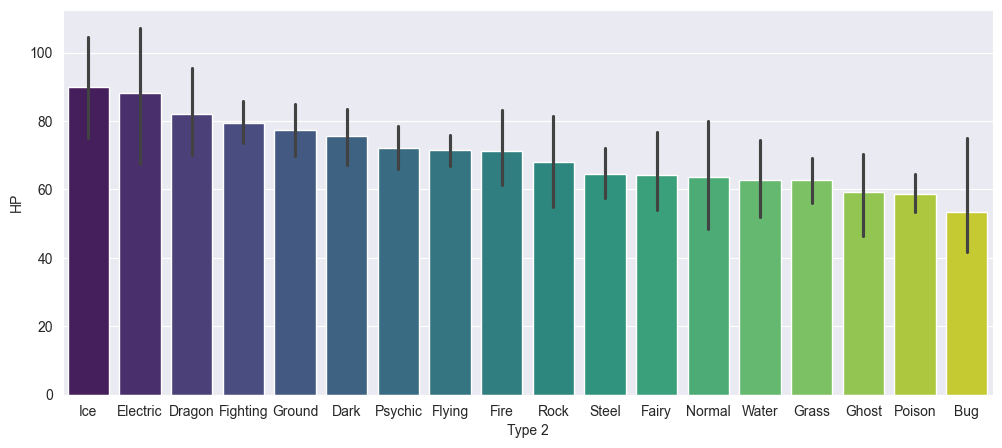

In [27]:
#implement ascending=false for appearance
type_order = df.groupby('Type 2')['HP'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='Type 2', y='HP', order=type_order, palette='viridis')
plt.show();

This shows me that ice, electric, and dragon pokemon typically have the highest hp

## Q5. Lets see if there are tradeoffs in strengths in pokemon. Do speedier characters have less attack, and vis versa?

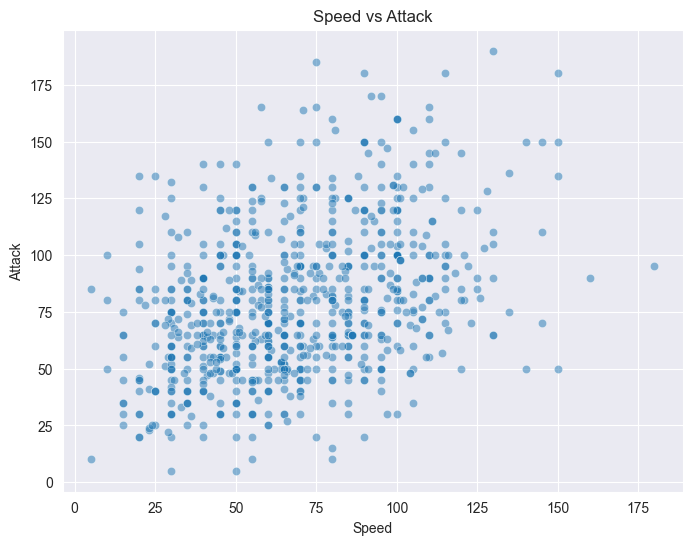

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Speed', y='Attack', alpha=0.5)
plt.title('Speed vs Attack')
plt.show()

This graph shows us there Speed and Attack are sureley tradeoffs, and its either you are in the middle, or extremely well suited for one of the two.

## Q6. Lets see the distribution of of health across all of the pokemon

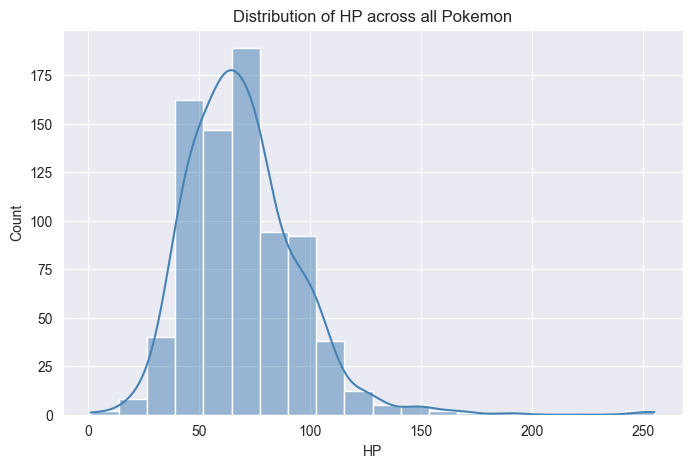

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='HP', bins=20, kde=True, color='steelblue')
plt.title('Distribution of HP across all Pokemon')
plt.show()

This graph shows something very cool and for sure something we expected. Mostly average, but with the mid-high being the strong suit. This supports my hypothesis that the best balance of anything that exists is mid-high. I feel like when I want to buy someone, or make a new friend, or whatever it may be, mid-high is the sweet spot